In [209]:
import numpy as np
import pandas as pd
import re
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt

In [211]:
df = pd.read_csv("output.csv")
df

,throw,x,y,z,position
0,Datas\71aZZ_176_20\2024-06-17_17-23-31\measure...,"1.897499919,1.79399991,1.759499907,1.724999905...","-7.762499809,-7.865999699,-7.831499577,-7.9004...","-0.103499994,-0.103499994,0.0,-0.103499994,-0....","(1.48559670781893,1.6310013717421126)"
1,Datas\71aZZ_176_20\2024-06-17_17-25-40\measure...,"1.31099999,1.379999995,1.31099999,1.276499987,...","-8.625,-8.694000244,-8.797499657,-8.728499413,...","-0.24149999,-0.275999993,-0.206999987,-0.44849...","(1.5130315500685871,1.0617283950617284)"
2,Datas\71aZZ_176_20\2024-06-27_13-34-09\measure...,"0.413999975,0.344999999,0.862499952,0.44849997...","-7.831499577,-7.934999943,-8.072999954,-8.0384...","-1.587000012,-1.31099999,-1.655999899,-1.51800...","(1.2315068493150685,1.621917808219178)"
3,Datas\71aZZ_176_20\2024-06-27_13-34-44\measure...,"-0.413999975,-0.793500006,-0.655499995,-0.5864...","-8.038499832,-7.900499821,-7.693500042,-7.9004...","-1.724999905,-1.31099999,-1.79399991,-1.345499...","(1.33013698630137,1.3520547945205479)"
4,Datas\71aZZ_176_20\2024-06-27_13-35-04\measure...,"-0.379500002,-0.034499999,0.24149999,0.8624999...","-7.65899992,-7.65899992,-7.520999908,-7.796999...","-1.276499987,-1.276499987,-1.138499975,-1.3454...","(1.082191780821918,0.8849315068493151)"
...,...,...,...,...,...
162,Datas\Wb0LQ_167_22\2024-07-01_11-01-45\measure...,"-1.207499981,-1.172999978,-0.896999955,-1.1039...","-8.038499832,-8.210999489,-8.142000198,-8.1075...","-0.413999975,-0.310499996,-0.413999975,-0.3104...","(0.1646090534979424,1.149519890260631)"
163,Datas\Wb0LQ_167_22\2024-07-01_11-02-14\measure...,"-1.655999899,-1.828499913,-1.897499919,-1.7594...","-8.072999954,-7.934999943,-8.00399971,-8.00399...","-0.7245,-0.896999955,-0.965999961,-0.965999961...","(1.244170096021948,1.0631001371742113)"
164,Datas\Wb0LQ_167_22\2024-07-01_11-02-58\measure...,"-0.759000003,-1.000499964,-0.896999955,-0.9314...","-8.279999733,-8.279999733,-8.107500076,-8.3144...","-0.413999975,-0.379500002,-0.48299998,-0.41399...","(1.4301369863013698,1.1123287671232878)"
165,Datas\Wb0LQ_167_22\2024-07-01_11-03-33\measure...,"-0.413999975,-0.551999986,-0.517499983,-0.5174...","-8.038499832,-8.210999489,-8.314499855,-8.2799...","-0.793500006,-0.448499978,-0.413999975,-0.5864...","(1.48559670781893,0.9245541838134431)"


In [213]:
# Function to convert string representation of list to actual list
def convert_to_list(string):
    try:
        return [float(item) for item in string.strip('[]').split(',')]
    except Exception as e:
        print(f"Error converting to list: {e}")
        return string

def convert_tuple_to_list(string):
    try:
        # Remove parentheses and split by comma, then convert to float
        elements = string.strip('()').split(',')
        return [float(elem) for elem in elements]
    except Exception as e:
        print(f"Error converting to tuple: {e}")
        return string
    
def euclidean_distance_error(y_true, y_pred):
    return K.sqrt(K.sum(K.square(y_pred - y_true), axis=-1))

def normalize_sequence(sequence):
    sequence = np.array(sequence).reshape(-1, 1)
    normalized_sequence = scaler_inputs.fit_transform(sequence).flatten()
    return normalized_sequence.tolist()

def normalize_sequence_pred(sequence):
    sequence = np.array(sequence).reshape(-1, 1)
    normalized_sequence = scaler_inputs.transform(sequence).flatten()
    return normalized_sequence.tolist()

In [214]:
# Convert string representations of lists to actual lists
df['x'] = df['x'].apply(convert_to_list)
df['y'] = df['y'].apply(convert_to_list)
df['z'] = df['z'].apply(convert_to_list)
df['position'] = df['position'].apply(convert_tuple_to_list)

In [217]:
df_data = df[["x","y","z"]]
df_targets = df[["position"]]

In [219]:
scaler_inputs = MinMaxScaler()
scaler_targets = MinMaxScaler()

In [220]:
df_targets

,position
0,"[1.48559670781893, 1.6310013717421126]"
1,"[1.5130315500685871, 1.0617283950617284]"
2,"[1.2315068493150685, 1.621917808219178]"
3,"[1.33013698630137, 1.3520547945205479]"
4,"[1.082191780821918, 0.8849315068493151]"
...,...
162,"[0.1646090534979424, 1.149519890260631]"
163,"[1.244170096021948, 1.0631001371742113]"
164,"[1.4301369863013698, 1.1123287671232878]"
165,"[1.48559670781893, 0.9245541838134431]"


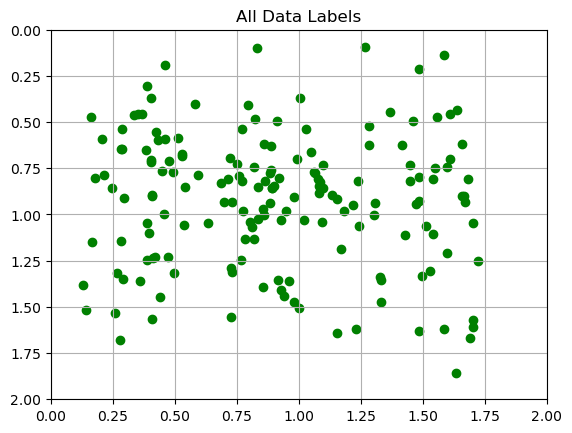

In [223]:
for i in range(len(df_targets)):
    plt.scatter(df_targets.values[i][0][0],df_targets.values[i][0][1],color="green")
    
plt.xlim([0,2])
plt.ylim([2,0])
plt.grid(True)
plt.title("All Data Labels");

In [224]:
df_data['x'] = df_data['x'].apply(normalize_sequence)
df_data['y'] = df_data['y'].apply(normalize_sequence)
df_data['z'] = df_data['z'].apply(normalize_sequence)

C:\Users\birke\AppData\Local\Temp\ipykernel_23620\1957025523.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_data['x'] = df_data['x'].apply(normalize_sequence)
C:\Users\birke\AppData\Local\Temp\ipykernel_23620\1957025523.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_data['y'] = df_data['y'].apply(normalize_sequence)
C:\Users\birke\AppData\Local\Temp\ipykernel_23620\1957025523.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

In [227]:
positions = np.array(df_targets['position'].tolist())

In [229]:
positions_normalized = scaler_targets.fit_transform(positions)

In [231]:
X = np.array(df_data[['x', 'y', 'z']].values.tolist()).transpose(0, 2, 1)
y = np.array(positions_normalized)

In [325]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=142)

(2.0, 0.0)

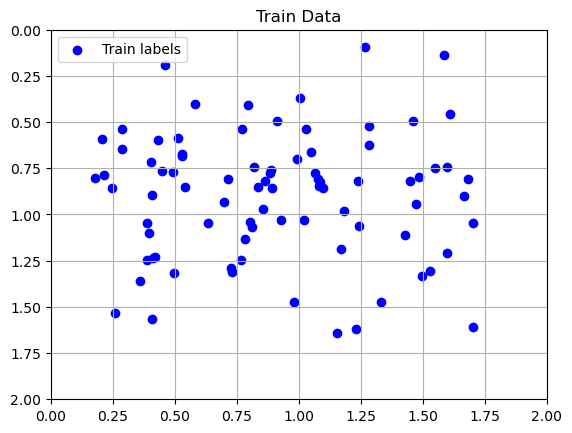

In [327]:
for i in y_train:
    p=i.copy()
    p = p.reshape(1,-1)
    targets_inversed = scaler_targets.inverse_transform(p)
    plt.scatter(targets_inversed[0][0], targets_inversed[0][1], color="b")

plt.legend(["Train labels"])
plt.title("Train Data")
plt.grid(True)
plt.xlim([0,2])
plt.ylim([2,0])

(0.0, 2.0)

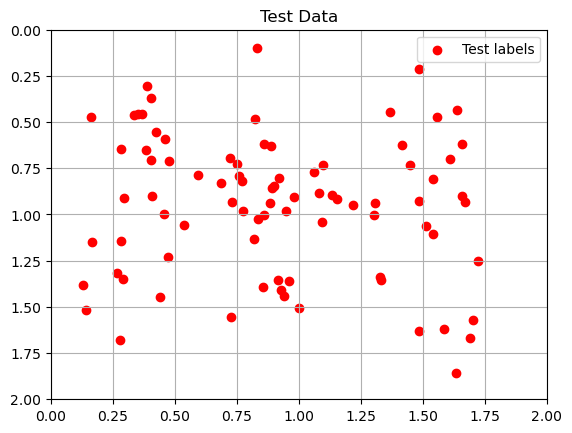

In [328]:
for i in y_test:
    p=i.copy()
    p = p.reshape(1,-1)
    targets_inversed = scaler_targets.inverse_transform(p)
    plt.scatter(targets_inversed[0][0], targets_inversed[0][1], color="r")

plt.legend(["Test labels"])
plt.title("Test Data")
plt.grid(True)
plt.ylim([2,0])
plt.xlim([0,2])

In [329]:
# Define data augmentation functions
def add_noise(sequence, noise_level=0.01):
    noise = np.random.normal(0, noise_level, sequence.shape)
    return sequence + noise

def scale_sequence(sequence, scale_range=(0.9, 1.1)):
    scale = np.random.uniform(scale_range[0], scale_range[1])
    return sequence * scale

def shift_sequence(sequence, shift_range=(-0.1, 0.1)):
    shift = np.random.uniform(shift_range[0], shift_range[1])
    return sequence + shift

# Apply data augmentation to the training data
augmented_X_train = []
augmented_y_train = []

for i in range(X_train.shape[0]):
    original_sequence = X_train[i]
    augmented_sequences = [
        add_noise(original_sequence),
        scale_sequence(original_sequence),
        shift_sequence(original_sequence)
    ]
    
    augmented_X_train.extend(augmented_sequences)
    augmented_y_train.extend([y_train[i]] * len(augmented_sequences))

augmented_X_train = np.array(augmented_X_train)
augmented_y_train = np.array(augmented_y_train)

In [330]:
#Model Structure
# add conv1d layer the parameter: kernel_regularizer='l2' for overfitting prevention
model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(Conv1D(filters=8, kernel_size=6, activation='relu', dilation_rate=25, kernel_regularizer='l2'))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=16, kernel_size=2, activation='relu', dilation_rate=50, kernel_regularizer='l2'))
model.add(MaxPooling1D(pool_size=2))
#model.add(BatchNormalization()) stabilize the learning process, might create a performance issue
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(16, activation='relu', kernel_regularizer='l2'))
model.add(Dropout(0.5))
model.add(Dense(2))

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

# Summary of the model
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 532, 8)         │           152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 266, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 216, 16)        │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 108, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 108, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1728)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │        27,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,122 (109.85 KB)

 Trainable params: 28,122 (109.85 KB)

 Non-trainable params: 0 (0.00 B)

In [332]:
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

In [333]:
type(augmented_X_train)

numpy.ndarray

In [334]:
# Train the model
# add fit function the parameter: callbacks=[early_stopping] for early stopping
history = model.fit(augmented_X_train, augmented_y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
loss, mae = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}, Test MAE: {mae}')

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.7731 - mae: 0.4510 - val_loss: 0.4782 - val_mae: 0.2133
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5201 - mae: 0.2897 - val_loss: 0.4706 - val_mae: 0.2659
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4696 - mae: 0.2755 - val_loss: 0.3929 - val_mae: 0.2133
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4287 - mae: 0.2718 - val_loss: 0.3732 - val_mae: 0.2321
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4010 - mae: 0.2757 - val_loss: 0.3380 - val_mae: 0.2202
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3725 - mae: 0.2762 - val_loss: 0.3159 - val_mae: 0.2186
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3420 - mae: 0.2597 - val_loss: 0.3007 - val_mae: 0.2218
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3134 - mae: 0.2432 - val_loss: 0.2719 - val_mae: 0.2017
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3099 - mae: 0.2661 - val_l

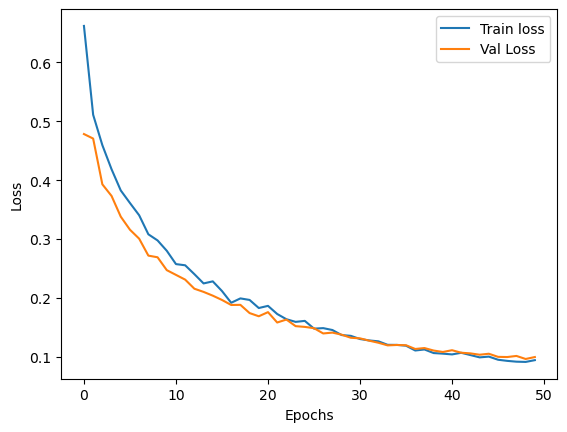

In [335]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train loss","Val Loss"])

# Pytorch Model

In [342]:
class CNNModel(nn.Module):
    def __init__(self, input_shape):
        super(CNNModel, self).__init__()
        
        # Assuming input_shape is (sequence_length, num_features)
        sequence_length, num_features = input_shape
        
        self.conv1 = nn.Conv1d(in_channels=num_features, out_channels=8, kernel_size=6, dilation=25)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(in_channels=8, out_channels=16, kernel_size=2, dilation=50)
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        self.dropout = nn.Dropout(0.5)
        
        # Calculate the flattened dimension after convolutions and pooling
        conv_output_size = self._get_conv_output_size(sequence_length, num_features)
        
        self.fc1 = nn.Linear(conv_output_size, 16)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(16, 2)  # Output layer for regression

    def _get_conv_output_size(self, sequence_length, num_features):
        with torch.no_grad():
            x = torch.zeros(1, num_features, sequence_length)
            x = self.conv1(x)
            x = self.pool1(x)
            x = self.conv2(x)
            x = self.pool2(x)
            x = x.view(1, -1)
            return x.size(1)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool2(x)
        x = self.dropout(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [343]:
X_train.shape

(83, 657, 3)

In [344]:
# Assuming input_shape = (sequence_length, num_features)
input_shape = (X_train.shape[1], X_train.shape[2])
model2 = CNNModel(input_shape)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)

# Summary of the model
print(model2)

CNNModel(
  (conv1): Conv1d(3, 8, kernel_size=(6,), stride=(1,), dilation=(25,))
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(8, 16, kernel_size=(2,), stride=(1,), dilation=(50,))
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=1728, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=2, bias=True)
)


In [345]:
# Convert the datasets to PyTorch tensors
X_train_tensor = torch.tensor(augmented_X_train, dtype=torch.float32).permute(0, 2, 1)
y_train_tensor = torch.tensor(augmented_y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).permute(0, 2, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [346]:
# Create TensorDataset and DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [347]:
train_loader = DataLoader(train_dataset, batch_size=33, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=33, shuffle=False)

In [348]:
X_train_tensor.shape

torch.Size([249, 3, 657])

In [349]:
X_test_tensor.shape

torch.Size([84, 3, 657])

Epoch 1/50, Train Loss: 0.17291034225906646, Val Loss: 0.10017275623977184
Epoch 2/50, Train Loss: 0.12878486726965224, Val Loss: 0.13249139115214348
Epoch 3/50, Train Loss: 0.11598533924136843, Val Loss: 0.10925132036209106
Epoch 4/50, Train Loss: 0.11263554649693626, Val Loss: 0.11398325115442276
Epoch 5/50, Train Loss: 0.11135356021778924, Val Loss: 0.11100561916828156
Epoch 6/50, Train Loss: 0.09939071110316686, Val Loss: 0.10646660625934601
Epoch 7/50, Train Loss: 0.10159644058772496, Val Loss: 0.10268000513315201
Epoch 8/50, Train Loss: 0.09544772867645536, Val Loss: 0.10929398238658905
Epoch 9/50, Train Loss: 0.09690896740981511, Val Loss: 0.10567725822329521
Epoch 10/50, Train Loss: 0.09090375900268555, Val Loss: 0.11150890216231346
Epoch 11/50, Train Loss: 0.09212411727224078, Val Loss: 0.10350171476602554
Epoch 12/50, Train Loss: 0.093320047216756, Val Loss: 0.1077454462647438
Epoch 13/50, Train Loss: 0.09916149186236518, Val Loss: 0.10500580072402954
Epoch 14/50, Train Loss:

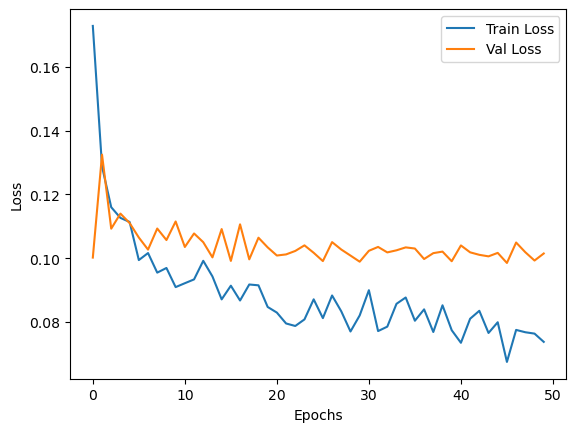

In [364]:
# Training loop
num_epochs = 50
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model2.train()
    running_loss = 0.0
    for i,(inputs, targets) in enumerate(train_loader):
        optimizer2.zero_grad()
        outputs = model2(inputs)
        loss = criterion(outputs, targets)
        
        # L2 regularization
        l2_reg = 0.0
        for param in model2.conv1.parameters():
            l2_reg += torch.sum(param ** 2)
        for param in model2.conv2.parameters():
            l2_reg += torch.sum(param ** 2)
        for param in model2.fc1.parameters():
            l2_reg += torch.sum(param ** 2)
            
        regularized_loss = 0.01 * l2_reg + loss
        regularized_loss.backward()
        #loss.backward()
        optimizer2.step()
        running_loss += loss.item()
        
        #loss += 0.01 * l2_reg
        
    
    epoch_loss = running_loss / i
    train_losses.append(epoch_loss)

    # Validation loop
    model2.eval()
    val_loss = 0.0
    with torch.no_grad():
        for i,(inputs, targets) in enumerate(test_loader):
            outputs = model2(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()
    
    val_loss = val_loss / i
    val_losses.append(val_loss)

    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss}, Val Loss: {val_loss}')

# Plotting the loss curves
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [351]:
# Evaluation on test set
model2.eval()
test_loss = 0.0
mae = 0.0
with torch.no_grad():
    for i,(inputs, targets) in enumerate(test_loader):
        outputs = model2(inputs)
        loss = criterion(outputs, targets)
        test_loss += loss.item()
        mae += F.l1_loss(outputs, targets, reduction='sum').item()

test_loss = test_loss / i
mae /= len(test_loader.dataset)

print(f'Test loss: {test_loss}, Test MAE: {mae}')

Test loss: 0.42154717445373535, Test MAE: 0.8815531957717169


# Prediction

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.signal import butter, filtfilt
import os
from pathlib import Path
from argparse import ArgumentParser
from shutil import copyfile
import csv
import cv2

In [33]:
def bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

def bandpass_magnitude_and_plot(data, lowcut, highcut, fs, threshold):
    # Apply bandpass filter
    filtered_x = bandpass_filter(data['x'], lowcut, highcut, fs)
    filtered_y = bandpass_filter(data['y'], lowcut, highcut, fs)
    filtered_z = bandpass_filter(data['z'], lowcut, highcut, fs)

    # Calculate magnitude
    magnitude = np.sqrt(filtered_x**2 + filtered_y**2 + filtered_z**2)
    avg_magnitude = np.mean(magnitude)
    
    # Detect fast movements based on threshold
    fast_movements_indices = np.asarray(np.where(magnitude > threshold)[0])
    
    if len(fast_movements_indices)>=1:
        start = fast_movements_indices[0]
        end = fast_movements_indices[-1]
        
    else:
        return int(0),int(0)
        
    return start,end

In [34]:
def order_points(pts):
    try:
        pts = np.reshape(pts, (4, 2))
    except:
        return (-1,-1)

    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect
def fitler_sacks(contours):
    sacks = list()
    mean = 0
    for index in range(1, len(contours)):
        cnt = contours[index]
        area = cv2.contourArea(cnt)
        mean = (mean + area) / 2

        if index == 1:
            mean = area

        if area <= mean / 2:
            break

        if area < TOO_SMALL:
            break

        sacks.append(cnt)

    return sacks
def find_field(image: Path) -> list[tuple[float, float]]:
    img = cv2.imread(str(image))

    imgray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(imgray, 127, 255, 0)

    contours, hierarchy = cv2.findContours(
        thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE
    )

    df = pd.DataFrame(
        hierarchy[0],
        columns=["nextSameLevel", "prviousSameLevel", "FirstChild", "Parent"],
    )
    fieldIdx = df.groupby("Parent").count().idxmax().nextSameLevel
    field = contours[fieldIdx]
    x, y, w, h = cv2.boundingRect(field)
    rect = np.array([[0, 0], [w, 0], [w, h], [0, h]], np.float32)
    epsilon = 0.1 * cv2.arcLength(field, True)
    approx = cv2.approxPolyDP(field, epsilon, True)
    
    if len(approx) != 4:
        return (-1,-1)
        
    rect2 = order_points(approx)

    m = cv2.getPerspectiveTransform(rect2, rect)

    dst = cv2.warpPerspective(img, m, (int(w), int(h)))
    dst = cv2.resize(dst, (int(w), int(w)), cv2.INTER_AREA)

    imgray = cv2.cvtColor(dst, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(imgray, 140, 255, 0)
    contours, hierarchy = cv2.findContours(
        thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE
    )
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    field_width = w
    sacks = fitler_sacks(contours)
    positions = []

    for sack in sacks:
        x, y, w, h = cv2.boundingRect(sack)
        center = (x + w / 2, y + h / 2)
        positions.append((center[0] / field_width * 2, center[1] / field_width * 2))

    return positions

In [35]:
main_directory = "PredictionData"
TOO_SMALL = 50
pred_df = pd.DataFrame(columns=["throw","x","y","z","position"])

In [36]:
i=0

for throwers in os.listdir(main_directory):
    if throwers=="Info.txt":
        continue
    else:
        for throw in os.listdir(main_directory+"/"+throwers):
            if throw.endswith(".jpg"):
                file_path_img=os.path.join(main_directory, throwers,throw)
                pos = find_field(file_path_img)
            elif throw.endswith(".csv"):
                file_path=os.path.join(main_directory, throwers,throw)
                real_df = pd.read_csv(file_path)
                real_df = real_df.drop((len(real_df)-1), axis=0)
                for col in real_df.columns:
                    real_df[col] = pd.to_numeric(real_df[col])
                start, end = bandpass_magnitude_and_plot(real_df, lowcut=0.1, highcut=10, fs=50, threshold=3)
                real_df = real_df[start:end]
                real_df_x = np.array(real_df["x"])
                real_df_y = np.array(real_df["y"])
                real_df_z = np.array(real_df["z"])
                pred_df["x"][i] = real_df_x
                pred_df["y"][i] = real_df_y
                pred_df["z"][i] = real_df_z
                new_row = pd.DataFrame({"throw":file_path,"x": [real_df_x], "y": [real_df_y], "z": [real_df_z], "position": [pos]})
                pred_df = pd.concat([pred_df, new_row], ignore_index=True)
                i=i+1
            else:
                continue

In [37]:
indexes_to_remove = pred_df.index[pred_df["position"]==(-1,-1)].to_list()
pred_df_removed = pred_df.drop(indexes_to_remove, axis=0)

indexes_to_remove2 = pred_df_removed.index[pred_df_removed["x"].apply(lambda x: len(x) == 0)].to_list()
pred_df_removed = pred_df_removed.drop(indexes_to_remove2, axis=0)

In [38]:
# Define the columns to pad
columns_to_pad = ["x", "y", "z"]
start_end_max_length = X.shape[1]

for index, row in pred_df_removed.iterrows():
    for col in columns_to_pad:
        array = row[col]
        while len(array) < start_end_max_length:
            array = np.append(array, 0)
        pred_df_removed.at[index, col] = array

In [39]:
y_true = pred_df_removed["position"]
pred_df_removed = pred_df_removed.drop(columns=["position"])

In [40]:
pred_df_removed

,throw,x,y,z
0,PredictionData\2024-06-27_15-15-34\measurement...,"[2.000999928, 2.27699995, 2.104500055, 2.20799...","[-6.658499718, -6.796499729, -6.968999863, -6....","[-4.001999855, -3.898499966, -3.518999815, -3...."
1,PredictionData\2024-06-27_15-16-15\measurement...,"[1.828499913, 1.724999905, 2.03550005, 1.93199...","[-6.934499741, -7.003499985, -6.830999851, -7....","[-4.105499744, -3.691499949, -4.484999657, -3...."
2,PredictionData\2024-06-27_15-17-30\measurement...,"[2.173500061, 2.03550005, 2.414999962, 2.24249...","[-7.244999886, -7.106999874, -6.934499741, -7....","[-3.622499943, -3.898499966, -3.622499943, -3...."
3,PredictionData\2024-06-27_15-18-06\measurement...,"[2.38049984, 2.552999973, 2.621999979, 2.62199...","[-6.658499718, -6.865499973, -6.658499718, -6....","[-3.760499954, -3.725999832, -4.071000099, -3...."
4,PredictionData\2024-06-27_15-18-50\measurement...,"[1.621500015, 1.069499969, 1.276499987, 1.7249...","[-7.03799963, -6.796499729, -6.865499973, -7.4...","[-4.071000099, -4.243499756, -4.347000122, -4...."
5,PredictionData\2024-06-27_15-19-54\measurement...,"[3.036000013, 2.86349988, 2.898000002, 2.58749...","[-13.799999237, -13.696499825, -13.523999214, ...","[-4.347000122, -4.001999855, -3.760499954, -3...."
6,PredictionData\2024-06-27_15-21-16\measurement...,"[1.483500004, 1.587000012, 1.069499969, 1.6215...","[-7.382999897, -7.003499985, -7.03799963, -7.0...","[-2.27699995, -2.27699995, -2.483999968, -2.96..."
7,PredictionData\2024-06-27_15-21-59\measurement...,"[2.621999979, 2.552999973, 2.38049984, 2.27699...","[-7.072499752, -6.69299984, -6.58949995, -6.62...","[-4.139999866, -3.863999844, -4.001999855, -4...."
8,PredictionData\2024-06-27_15-22-46\measurement...,"[1.828499913, 1.621500015, 1.759499907, 1.9319...","[-7.003499985, -7.03799963, -7.175999641, -7.4...","[-3.725999832, -4.036499977, -3.794999838, -3...."
9,PredictionData\2024-06-27_15-23-30\measurement...,"[1.069499969, 0.862499952, 1.172999978, 1.0349...","[-6.899999619, -6.968999863, -6.865499973, -6....","[-3.449999809, -3.518999815, -3.691499949, -3...."


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1. throw prediction-----> Predicted value: [0.9589896 1.0661746]     Actual value: (1.095890410958904, 0.7424657534246575)
1. Throw DISTANCE----> Distance between prediction-actual 35.1cm
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2. throw prediction-----> Predicted value: [0.9939373 0.9970355]     Actual value: (0.46164383561643835, 0.6506849315068494)
2. Throw DISTANCE----> Distance between prediction-actual 63.5cm
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3. throw prediction-----> Predicted value: [0.97711915 1.0977544 ]     Actual value: (0.5356164383561643, 0.7479452054794521)
3. Throw DISTANCE----> Distance between prediction-actual 56.3cm
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4. throw prediction-----> Predicted value: [1.0024623  0.99506855]     Actual value: (0.9095890410958904, 0.4410958904109589)
4. Throw DISTANCE----> Distance between prediction-actual 56.2cm
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5. throw prediction-----> Predicted value: [0.994

Text(0.5, 1.0, 'Predcition real labels (X: Prediction, O: Actual)')

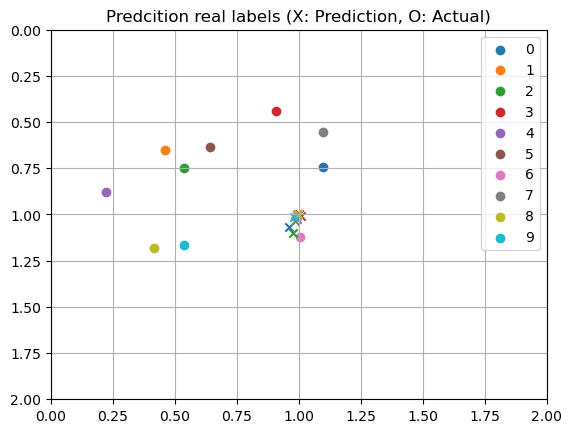

In [41]:
legends=[]

for i in y_true:
    plt.scatter(i[0][0], i[0][1], marker="o")
    plt.legend(y_true.index)
    
    
for i in range(len(pred_df_removed)):
    prediction_data_df = pred_df_removed[pred_df_removed.index == i]
    prediction_data_df_label=y_true[i]

    prediction_data_df_normalized = prediction_data_df.copy()
    prediction_data_df_normalized['x'] = prediction_data_df['x'].apply(normalize_sequence_pred)
    prediction_data_df_normalized['y'] = prediction_data_df['y'].apply(normalize_sequence_pred)
    prediction_data_df_normalized['z'] = prediction_data_df['z'].apply(normalize_sequence_pred)

    X_pred = np.array(prediction_data_df_normalized[['x', 'y', 'z']].values.tolist()).transpose(0, 2, 1)

    pred = scaler_targets.inverse_transform(model.predict(X_pred))
    plt.scatter(pred[0][0], pred[0][1], marker="x")
    legends.append(i)
    
    distance_pred_true = 100*np.sqrt((((pred[0][0]) - (prediction_data_df_label[0][0]))**2) + (((pred[0][1]) - (prediction_data_df_label[0][1]))**2))
    print(str(i+1)+". throw prediction----->"+" Predicted value:", str(pred[0])+ "     Actual value: " + str(prediction_data_df_label[0]))
    print(str(i+1)+". Throw DISTANCE---->"+" Distance between prediction-actual "+ str(distance_pred_true.round(1))+ "cm")
    
plt.legend(legends)
plt.grid(True)
plt.xlim([0,2])
plt.ylim([2,0])
plt.title("Predcition real labels (X: Prediction, O: Actual)")